In [1]:
req.libs <- c("BuenRTools", "dplyr", "data.table", "ggplot2", "scattermore", "future.apply", "stringi")
lapply(req.libs, function(x){
    suppressMessages(library(x, character.only = TRUE))})

[[1]]
 [1] "BuenRTools"           "ggplot2"              "SummarizedExperiment"
 [4] "Biobase"              "GenomicRanges"        "GenomeInfoDb"        
 [7] "IRanges"              "S4Vectors"            "BiocGenerics"        
[10] "stats4"               "MatrixGenerics"       "matrixStats"         
[13] "Matrix"               "stats"                "graphics"            
[16] "grDevices"            "utils"                "datasets"            
[19] "methods"              "base"                

[[2]]
 [1] "dplyr"                "BuenRTools"           "ggplot2"             
 [4] "SummarizedExperiment" "Biobase"              "GenomicRanges"       
 [7] "GenomeInfoDb"         "IRanges"              "S4Vectors"           
[10] "BiocGenerics"         "stats4"               "MatrixGenerics"      
[13] "matrixStats"          "Matrix"               "stats"               
[16] "graphics"             "grDevices"            "utils"               
[19] "datasets"             "methods"              "base"                

[[3]]
 [1] "data.table"           "dplyr"                "BuenRTools"          
 [4] "ggplot2"              "SummarizedExperiment" "Biobase"             
 [7] "GenomicRanges"        "GenomeInfoDb"         "IRanges"             
[10] "S4Vectors"            "BiocGenerics"         "stats4"              
[13] "MatrixGenerics"       "matrixStats"          "Matrix"              
[16] "stats"                "graphics"             "grDevices"           
[19] "utils"                "datasets"             "methods"             
[22] "base"                

[[4]]
 [1] "data.table"           "dplyr"                "BuenRTools"          
 [4] "ggplot2"              "SummarizedExperiment" "Biobase"             
 [7] "GenomicRanges"        "GenomeInfoDb"         "IRanges"             
[10] "S4Vectors"            "BiocGenerics"         "stats4"              
[13] "MatrixGenerics"       "matrixStats"          "Matrix"              
[16] "stats"                "graphics"             "grDevices"           
[19] "utils"                "datasets"             "methods"             
[22] "base"                

[[5]]
 [1] "scattermore"          "data.table"           "dplyr"               
 [4] "BuenRTools"           "ggplot2"              "SummarizedExperiment"
 [7] "Biobase"              "GenomicRanges"        "GenomeInfoDb"        
[10] "IRanges"              "S4Vectors"            "BiocGenerics"        
[13] "stats4"               "MatrixGenerics"       "matrixStats"         
[16] "Matrix"               "stats"                "graphics"            
[19] "grDevices"            "utils"                "datasets"            
[22] "methods"              "base"                

[[6]]
 [1] "future.apply"         "future"               "scattermore"         
 [4] "data.table"           "dplyr"                "BuenRTools"          
 [7] "ggplot2"              "SummarizedExperiment" "Biobase"             
[10] "GenomicRanges"        "GenomeInfoDb"         "IRanges"             
[13] "S4Vectors"            "BiocGenerics"         "stats4"              
[16] "MatrixGenerics"       "matrixStats"          "Matrix"              
[19] "stats"                "graphics"             "grDevices"           
[22] "utils"                "datasets"             "methods"             
[25] "base"                

[[7]]
 [1] "stringi"              "future.apply"         "future"              
 [4] "scattermore"          "data.table"           "dplyr"               
 [7] "BuenRTools"           "ggplot2"              "SummarizedExperiment"
[10] "Biobase"              "GenomicRanges"        "GenomeInfoDb"        
[13] "IRanges"              "S4Vectors"            "BiocGenerics"        
[16] "stats4"               "MatrixGenerics"       "matrixStats"         
[19] "Matrix"               "stats"                "graphics"            
[22] "grDevices"            "utils"                "datasets"            
[25] "methods"              "base"

In [2]:
atac.dir <- "/fab/AlignedData/rsav_minimorf/igvf_pipeline/"
barcode_files <- list.files(
  path = atac.dir,
  pattern = ".barcode.summary.csv$",  # regex for exact match
  recursive = TRUE,                         # search subdirectories
  full.names = TRUE                         # return full paths
)

I'm doing a preliminary filter of 200 ATAC frags per cell, just to make the data size more manageable. 
This doesn't take into account the seq depth and dup rate. 
We are calculating library size given unique reads and duplicate reads, given Lander-Waterman equation

some more info is here: https://sourceforge.net/p/samtools/mailman/samtools-help/thread/DUB405-EAS154589A1ACEF2BE4C573D4592180@phx.gbl/

also see: https://www.nature.com/articles/nmeth.2375

C/X = 1 - exp( -N/X )

where
X = number of distinct molecules in library
N = number of read pairs
C = number of distinct fragments observed in read pairs



In [3]:
plan(multisession, workers = 10)  # use 10 cores
results <- future_lapply(barcode_files, function(x){
    new.atac <- fread(x)
    cutoff <- 200
    filt <- new.atac[total >= cutoff]
    filt <- filt[!grepl("whitelist", barcode)]
    filt$total.mapped.reads <- filt$total - filt$unmapped - filt$lowmapq
    filt$unique.mapped.reads <- filt$total.mapped.reads - filt$duplicate
    filt[, libsize := total.mapped.reads]
    filt[total.mapped.reads != unique.mapped.reads, libsize := mapply(function(tot, uniq) {
        round(uniroot(function(x) x * (1 - exp(-tot / x)) - uniq,
                        lower = 1, upper = 1e8, tol = 1e-7)$root)
    }, total.mapped.reads, unique.mapped.reads)]
    return(filt)
})

In [4]:
meta.df <- do.call(rbind, results)
meta.df$sublibrary <- stri_split_fixed(meta.df$barcode, pattern = "_", simplify = TRUE)[,2]
meta.df <- meta.df %>% group_by(sublibrary)%>%
arrange(-total.mapped.reads)%>%
mutate(n=row_number())

In [5]:
table(meta.df$sublibrary)


SS-PKR-608 SS-PKR-609 SS-PKR-610 SS-PKR-611 SS-PKR-612 SS-PKR-613 SS-PKR-614 
     26576      26694      26536      26182      25075      28547      24493 
SS-PKR-615 SS-PKR-616 SS-PKR-617 SS-PKR-618 SS-PKR-619 SS-PKR-620 SS-PKR-621 
     25953      23088      25641      24595      26361      60637      40284 
SS-PKR-622 SS-PKR-623 SS-PKR-624 SS-PKR-625 SS-PKR-626 SS-PKR-627 SS-PKR-628 
     46448      35309      35341      31584      59484      24565      27588 
SS-PKR-629 SS-PKR-630 SS-PKR-631 SS-PKR-632 SS-PKR-633 SS-PKR-634 SS-PKR-635 
     27552       8714     115146      23601      26349      24742      25380 
SS-PKR-636 SS-PKR-637 SS-PKR-639 SS-PKR-640 SS-PKR-641 SS-PKR-642 SS-PKR-643 
     33527      32916      26199      33469      29108      30797       8932 
SS-PKR-644 
      8808 

This is a plot of the ATAC fragments per cell. 
PKR630 got slightly fewer reads than we wanted, but we'll just filter out low quality cells later.
And sublibs like 625, 620, 626, 631 got seqed deeply, so there is more debris coming through the cutoff of 200.
I aliquotted a maximum of 30k cells in each sublibrary, so i'll filter each sublib to have 30k cells or fewer  

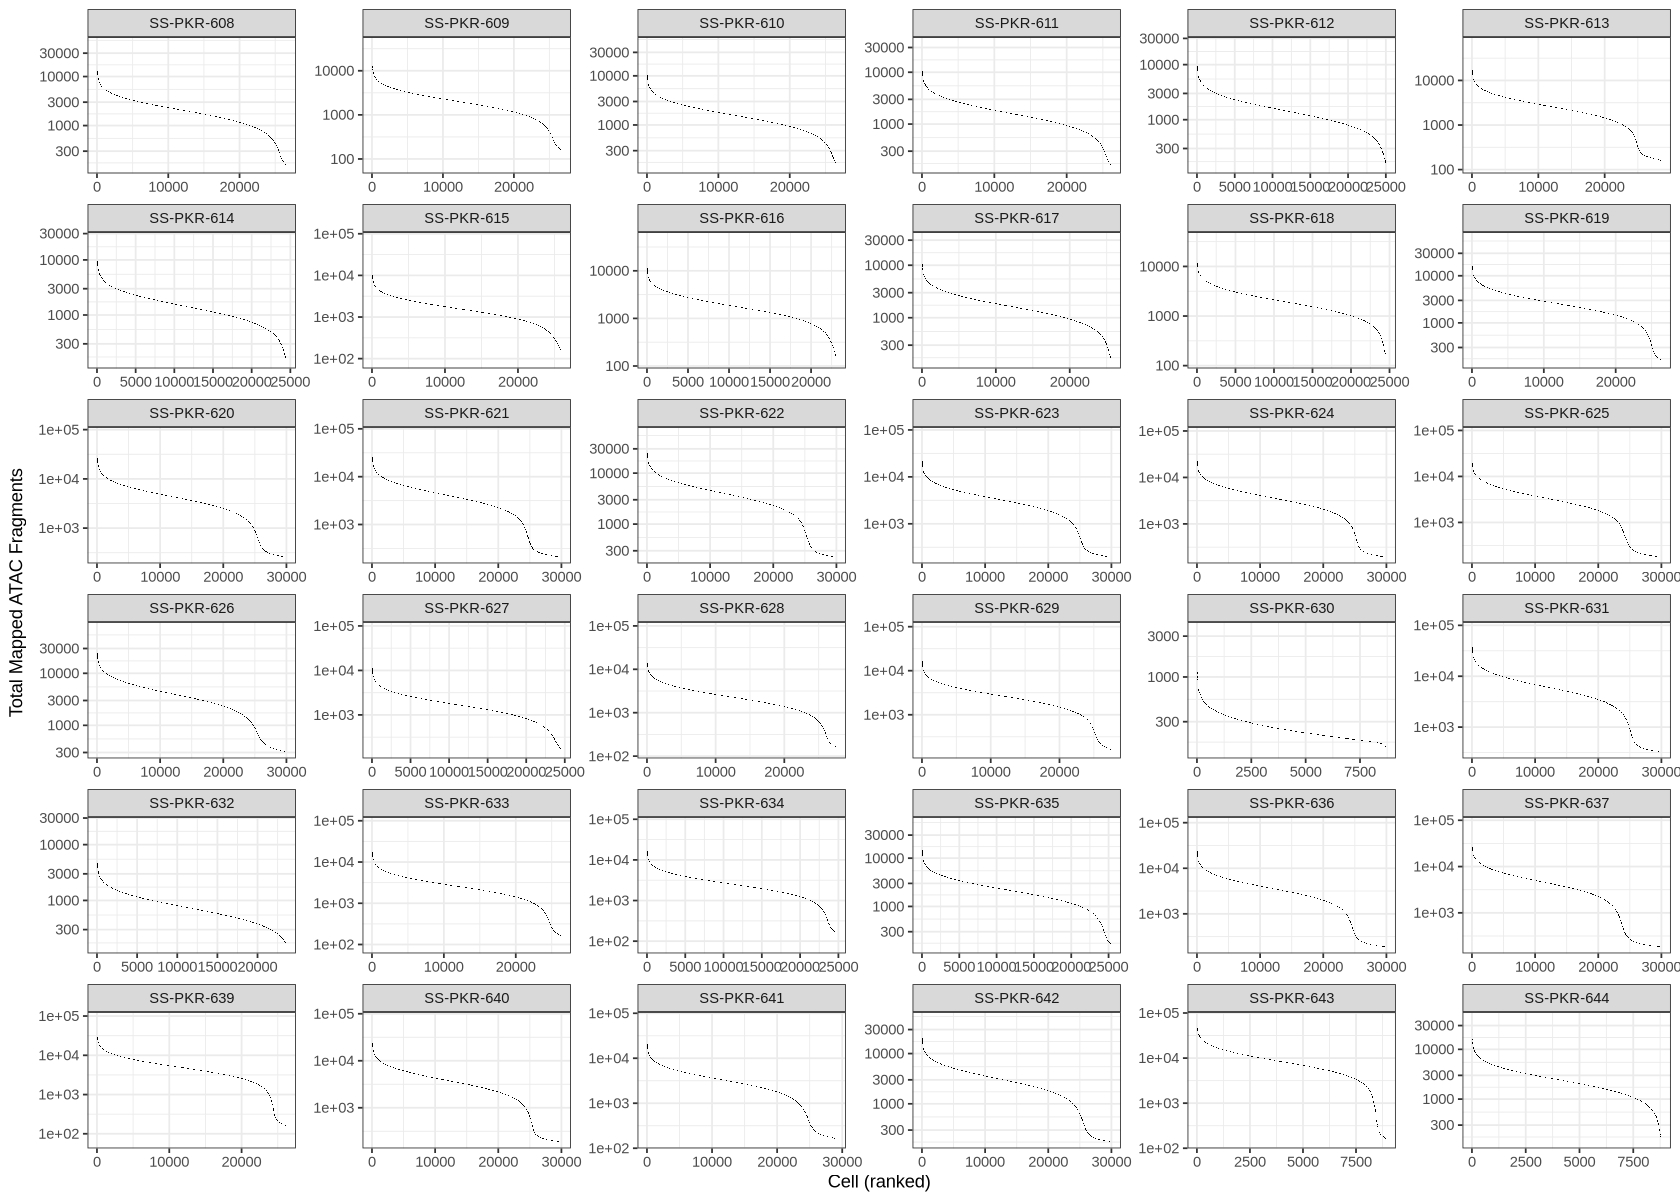

In [6]:
options(repr.plot.width = 14, repr.plot.height = 10)

meta.df %>%
filter(total.mapped.reads<=100000)%>%
filter(n<=30000)%>%
ggplot(aes(x=n, y=total.mapped.reads))+
geom_scattermore()+
theme_bw()+
scale_y_continuous(trans = "log10")+
facet_wrap(~sublibrary, scales = "free")+
theme_bw()+
xlab("Cell (ranked)")+
ylab("Total Mapped ATAC Fragments")

In [6]:
meta.df.filt <- meta.df %>% filter(n<30000)
dim(meta.df.filt)

[1] 931267     10

For the sake of computational space, we will start off using a peak set that we defined in an earlier iteration of the project, just as a way to calculate FRIP for cell filtering.
Once we have our final set of cells, we will re-call peaks, and then recreate counts matrices accordingly. 

In [7]:
peaks <- fread("../data/peaks/all_cleaned_peaks.20240623.bed")
peaks <- GRanges(
    seqnames = peaks$V1,
    ranges = IRanges(start = peaks$V2, end = peaks$V3)
)

In [8]:
atac.dir <- "/fab/AlignedData/rsav_minimorf/igvf_pipeline/"
frag_files <- list.files(
  path = atac.dir,
  pattern = ".fragments.tsv.gz$",  # regex for exact match
  recursive = TRUE,                         # search subdirectories
  full.names = TRUE                         # return full paths
)

this next block took a while to run and def could be written to run faster.. but oh well 

In [9]:
plan(multisession, workers = 4)  # use 10 cores
results <- future_lapply(frag_files, function(x){
    suppressPackageStartupMessages(library(dplyr))
    GA <- BuenRTools::fragsToRanges(fragFile = x,
                                    barcodeList = meta.df.filt$barcode, 
                startsAre0based = TRUE)
    
    ovPEAKStarts <- findOverlaps(query = peaks, subject = resize(GA, 
        width = 1, fix = "start"))
    ovPEAKEnds <- findOverlaps(query = peaks, subject = resize(GA, 
            width = 1, fix = "end"))
    validIdx <- unique(c(subjectHits(ovPEAKStarts), subjectHits(ovPEAKEnds)))
    peak.frags <- as.data.table(GA[validIdx])
    peak.frags <- peak.frags[, .N, by = V4]
    colnames(peak.frags) <- c("barcode", "unique.mapped.reads.in.peaks")
    return(peak.frags)
}, future.seed = TRUE)

Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..




   ____                       _____  _______             _
  |  _ \                     |  __ \|__   __|           | |
  | |_) | _   _   ___  _ __  | |__) |  | |  ___    ___  | | ___
  |  _ < | | | | / _ \| '_ \ |  _  /   | | / _ \  / _ \ | |/ __|
  | |_) || |_| ||  __/| | | || | \ \   | || (_) || (_) || |\__ \
  |____/  \__,_| \___||_| |_||_|  \_\  |_| \___/  \___/ |_||___/







Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..




   ____                       _____  _______             _
  |  _ \                     |  __ \|__   __|           | |
  | |_) | _   _   ___  _ __  | |__) |  | |  ___    ___  | | ___
  |  _ < | | | | / _ \| '_ \ |  _  /   | | / _ \  / _ \ | |/ __|
  | |_) || |_| ||  __/| | | || | \ \   | || (_) || (_) || |\__ \
  |____/  \__,_| \___||_| |_||_|  \_\  |_| \___/  \___/ |_||___/







Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..




   ____                       _____  _______             _
  |  _ \                     |  __ \|__   __|           | |
  | |_) | _   _   ___  _ __  | |__) |  | |  ___    ___  | | ___
  |  _ < | | | | / _ \| '_ \ |  _  /   | | / _ \  / _ \ | |/ __|
  | |_) || |_| ||  __/| | | || | \ \   | || (_) || (_) || |\__ \
  |____/  \__,_| \___||_| |_||_|  \_\  |_| \___/  \___/ |_||___/







Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..
Reading in fragment file ..
Reading only select barcodes specified within list from file ..




   ____                       _____  _______             _
  |  _ \                     |  __ \|__   __|           | |
  | |_) | _   _   ___  _ __  | |__) |  | |  ___    ___  | | ___
  |  _ < | | | | / _ \| '_ \ |  _  /   | | / _ \  / _ \ | |/ __|
  | |_) || |_| ||  __/| | | || | \ \   | || (_) || (_) || |\__ \
  |____/  \__,_| \___||_| |_||_|  \_\  |_| \___/  \___/ |_||___/







In [14]:
frip.df <- do.call(rbind, results)
meta.df.filt <- meta.df.filt %>% left_join(frip.df) %>% dplyr::select(-n)
meta.df.filt$FRIP <- meta.df.filt$unique.mapped.reads.in.peaks/meta.df.filt$unique.mapped.reads

Joining with `by = join_by(barcode)`


In [17]:
fwrite(meta.df.filt, "/mnt/users/rachelsavage/paper_minimorf/data/initial_filtering/atac.full.metadata.tsv")

now let's make FRIP plots! 

In [20]:
head(meta.df.filt)

barcode,total,duplicate,unmapped,lowmapq,total.mapped.reads,unique.mapped.reads,libsize,sublibrary,unique.mapped.reads.in.peaks
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<int>
GACGGATTTAAGCGTTGTCGCTAT_SS-PKR-626,1004949,238217,103725,107832,793392,555175,1040848,SS-PKR-626,229248
TCTCACGGTACCGAGCGCAATCCG_SS-PKR-642,543967,153533,33442,52239,458286,304753,520706,SS-PKR-642,33267
GCTAACTCTTGACTCTTCATTGAG_SS-PKR-610,474185,95708,34443,47962,391780,296072,665133,SS-PKR-610,22926
GTCTTGGCTGCATAGTGTTAGCCT_SS-PKR-620,435904,145703,30718,43327,361859,216156,318223,SS-PKR-620,22354
TACCACCAGCACTGTCTCAGATTC_SS-PKR-641,413008,138963,23340,44447,345221,206258,303720,SS-PKR-641,68661
GACGGATTTGTTCTCCGATCAGCG_SS-PKR-622,263429,46097,28013,28026,207390,161293,394474,SS-PKR-622,58880


In [48]:
frip.cutoff <- 0.2
unique.mapped.reads.low <- 500
unique.mapped.reads.high <- 10000

[1] 762374     11

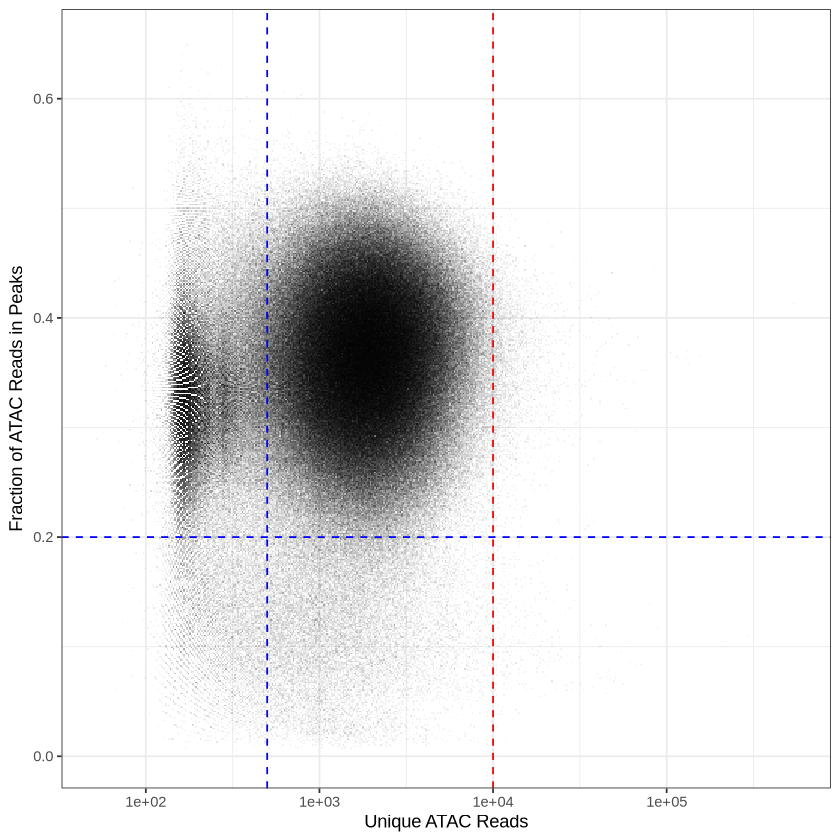

In [56]:
meta.df.filt %>% 
ggplot(aes(x=unique.mapped.reads, y=FRIP))+
geom_scattermore(alpha=0.05)+
theme_bw()+
scale_x_continuous(trans = "log10")+
geom_hline(yintercept = frip.cutoff, color = "blue", linetype = "dashed")+
geom_vline(xintercept = unique.mapped.reads.low, color = "blue", linetype = "dashed")+
geom_vline(xintercept = unique.mapped.reads.high, color = "red", linetype = "dashed")+
xlab("Unique ATAC Reads")+
ylab("Fraction of ATAC Reads in Peaks")

meta.df.filt %>% 
filter(FRIP>=frip.cutoff) %>% 
filter(unique.mapped.reads>=unique.mapped.reads.low) %>%
filter(unique.mapped.reads<=unique.mapped.reads.high) %>% dim()

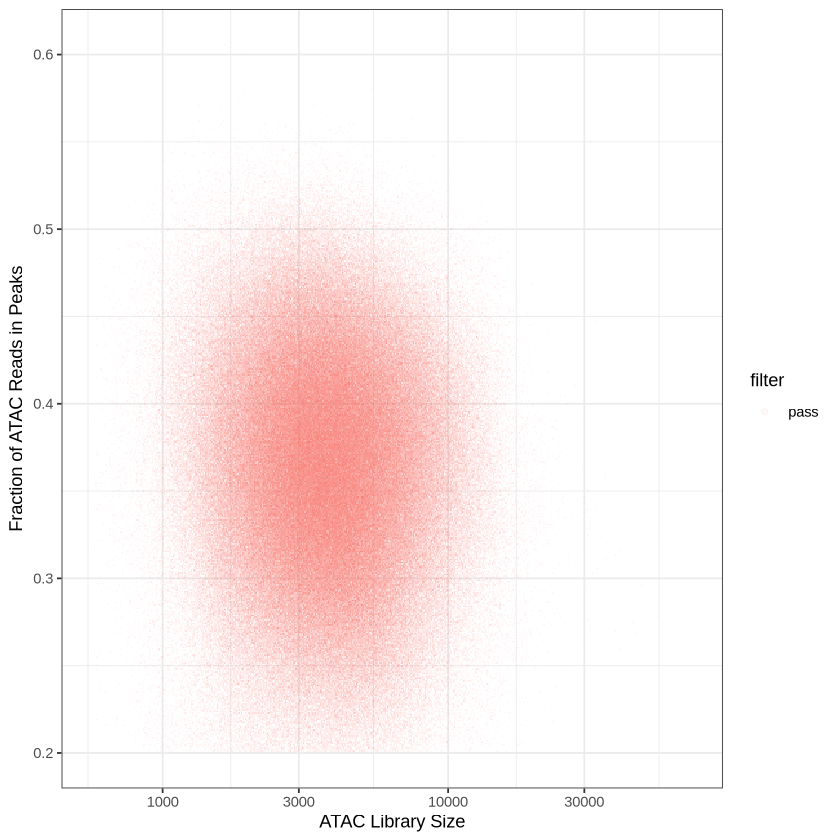

In [62]:
meta.df.filt %>% 
mutate(filter = ifelse(FRIP>=frip.cutoff & 
                       unique.mapped.reads>=unique.mapped.reads.low & 
                       unique.mapped.reads<=unique.mapped.reads.high, 
                     "pass","fail"))%>%
filter(filter == "pass")%>%
ggplot(aes(x=libsize, y=FRIP, color = filter))+
geom_scattermore(alpha=0.05)+
theme_bw()+
scale_x_continuous(trans = "log10")+
xlab("ATAC Library Size")+
ylab("Fraction of ATAC Reads in Peaks")

In [63]:
meta <- meta.df.filt %>% 
filter(FRIP>=frip.cutoff) %>% 
filter(unique.mapped.reads>=unique.mapped.reads.low) %>%
filter(unique.mapped.reads<=unique.mapped.reads.high) 

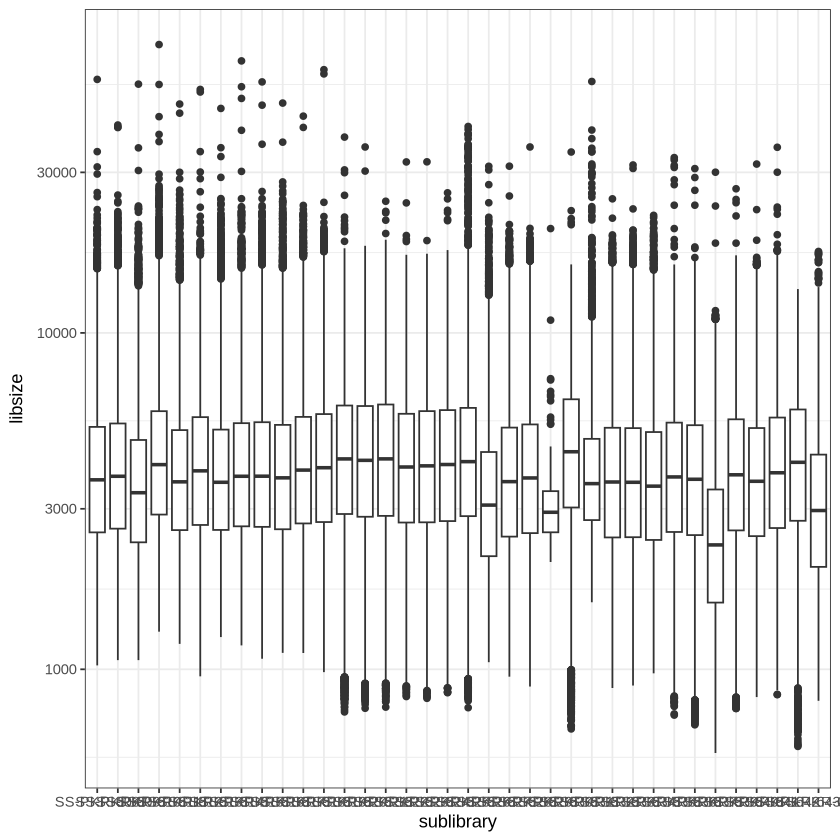

In [64]:
meta %>% 
ggplot(aes(x=sublibrary, y=libsize))+
geom_boxplot()+
theme_bw()+
scale_y_continuous(trans = "log10")

In [69]:
fwrite(meta, "/mnt/users/rachelsavage/paper_minimorf/data/initial_filtering/atac.filtered.metadata.tsv")